##
            TAVILY [WEB-SEARCH] 
                ||      Tool Call
                ||
                VV
    START -> CHATBOT -> END
                ^^
                ||
            LLM-Prompt

Making the websearch tool integration with TAVILY for web-search and state awarness

In [5]:
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from typing import Annotated
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [6]:
from langchain_ollama import ChatOllama


# Load local model
llm = ChatOllama(
    model="gpt-oss:120b-cloud",
    temperature=0,
)

In [7]:
# Define the state
class ChatState(TypedDict):
    user_input: str
    response: str

In [9]:
# Node function
def chatbot(state: ChatState):
    answer = llm.invoke(state["user_input"])

    return {
        "response": answer.content
    }


In [10]:
# Build graph
builder = StateGraph(ChatState)

builder.add_node("chatbot", chatbot)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile()


In [11]:
# Run chatbot
while True:
    question = input("You: ")

    if question.lower() in ["exit", "quit"]:
        break

    result = graph.invoke({
        "user_input": question
    })

    print("Bot:", result["response"])

Bot: Hello! I’m doing great, thank you for asking. How can I help you today?


## Chat bot with tools

In [13]:
from langchain_tavily import TavilySearch

In [15]:
from dotenv import load_dotenv
import os

load_dotenv()

tavily_key = os.getenv("TAVILY_API_KEY")

print(tavily_key[:10])

tvly-dev-1


In [17]:
from langchain_tavily import TavilySearch

search = TavilySearch(
    max_results=5,
    topic="news"
)

In [18]:
results = search.invoke("Latest AI news")
print(results)

{'query': 'Latest AI news', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-may-2026', 'title': 'The latest AI news we announced in May 2026', 'content': "May 2026 was packed with AI news. At Google I/O 2026, we officially entered the agentic Gemini era with the launch of Gemini 3.5 — which delivers frontier intelligence for agents and coding — and Gemini Omni, where Gemini’s ability to reason meets the ability to create. The Android Show set the stage with brand-new hardware built specifically for these tools, including the Googlebook from our hardware partners. We also broadened our personal wellness tools with the new Google Health app and [...] Breadcrumb\n\n1. Home\n2. Innovation & AI\n3. Technology\n4. AI\n\n# The latest AI news we announced in May 2026\n\nJun 05, 2026\n\n|\n\n x.com\n Facebook\n LinkedIn\n Mail\n\nHere’s a recap of our biggest AI updates from May, including anno

In [19]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

In [20]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

## Generating news letter

In [21]:
news = search.invoke("Latest AI news today")

prompt = f"""
Create a professional newsletter from the following news.

{news}
"""

response = llm.invoke(prompt)

print(response.content)

## AI Pulse: May-July 2026 - Navigating the Next Wave of Innovation and Impact

**Issue No. 07.2026 | July 15, 2026**

---

The past few months have underscored the accelerating pace of AI development, marked by groundbreaking model releases, significant infrastructure challenges, evolving economic landscapes, and a growing spotlight on ethical and regulatory considerations. From advanced "agentic" AI capabilities to the immense energy demands of data centers, the industry is navigating a period of unprecedented transformation and scrutiny.

---

### **Frontier AI Models and Agentic Capabilities Emerge**

The AI landscape is witnessing a surge in sophisticated models designed for greater autonomy and reasoning:

*   **Google's "Agentic Gemini Era":** At Google I/O 2026, Google officially launched **Gemini 3.5**, delivering "frontier intelligence for agents and coding." This was complemented by **Gemini Omni**, which combines Gemini's reasoning prowess with creative capabilities. The ev

## Using langgraph

In [22]:
from typing import TypedDict

class NewsletterState(TypedDict):
    topic: str
    news: str
    newsletter: str

In [23]:
def search_news(state):
    news = search.invoke(state["topic"])

    return {
        "news": str(news)
    }

In [24]:
def write_newsletter(state):
    prompt = f"""
    Create a newsletter from this information.

    {state['news']}
    """

    response = llm.invoke(prompt)

    return {
        "newsletter": response.content
    }

In [25]:
from langgraph.graph import StateGraph

builder = StateGraph(NewsletterState)

builder.add_node("search", search_news)
builder.add_node("writer", write_newsletter)

builder.set_entry_point("search")

builder.add_edge("search", "writer")

builder.set_finish_point("writer")

graph = builder.compile()

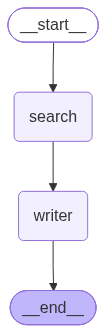

In [27]:
# for visualization of the graphs

from IPython.display import display, Markdown, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    display(Markdown(f"Error displaying graph: {e}"))

In [26]:
result = graph.invoke(
    {
        "topic": "Latest AI News"
    }
)

print(result["newsletter"])

## AI Pulse: May-July 2026 — The Agentic Era, Global Competition, and Infrastructure Demands

Welcome to AI Pulse, your essential digest of the latest breakthroughs and trends shaping the world of Artificial Intelligence! The past few months have been nothing short of transformative, with major announcements from tech giants, emerging global players, and critical discussions around AI's societal impact.

---

### Google Ignites the Agentic Gemini Era

May 2026 marked a pivotal moment for Google AI, as the company officially ushered in the "agentic Gemini era" at Google I/O. Key announcements included:

*   **Gemini 3.5:** Launched to deliver frontier intelligence specifically for agents and coding applications, promising advanced capabilities for complex tasks.
*   **Gemini Omni:** Introduced as a powerful new iteration where Gemini's reasoning prowess meets its ability to create, pushing the boundaries of generative AI.
*   **New Hardware:** The Android Show unveiled brand-new hardwar